In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

import warnings
warnings.filterwarnings('ignore')

# ==============================
# 2. Dataset (From your project)
# ==============================
data = {
    'N_P_pct': [100, 50, 75, 125, 150, 175, 200],
    'ht_30': [86.93, 94.26, 88.06, 85.13, 94.4, 87.93, 91.8],
    'ht_45': [104, 111.53, 105.6, 104.6, 105.5, 106.3, 110],
    'leaves_30':[4.13, 3.93, 3.86, 4.4, 4.46, 3.93, 3.93],
    'leaves_45':[6.0, 5.9, 5.6, 5.9, 5.9, 5.8, 5.6],
    'yield_kg': [5.80, 5.83, 6.47, 5.50, 5.90, 6.50, 6.07]
}

df = pd.DataFrame(data)

# ==============================
# 3. Data Augmentation
# ==============================
np.random.seed(42)
noise = np.random.normal(0, 0.05, (50, len(df.columns)))

df_aug = pd.concat([
    df,
    pd.DataFrame(
        df.values[np.random.choice(len(df), 50)] + noise,
        columns=df.columns
    )
], ignore_index=True)

# ==============================
# 4. Features & Target
# ==============================
X = df_aug.drop('yield_kg', axis=1)
y = df_aug['yield_kg']

# ==============================
# 5. Scaling
# ==============================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 6. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ==============================
# 7. Model Evaluation Function
# ==============================
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)

    return rmse, r2, mae

# ==============================
# 8. Baseline Models
# ==============================
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVM': SVR()
}

print("\nBaseline Model Performance")
print("-"*50)

for name, model in models.items():
    rmse, r2, mae = evaluate_model(model, X_train, X_test, y_train, y_test)
    print(f"{name:20} RMSE: {rmse:.3f} | R2: {r2:.3f} | MAE: {mae:.3f}")

# ==============================
# 9. Cross Validation (Better Evaluation)
# ==============================
print("\nCross Validation (R2 Scores)")
print("-"*50)

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    print(f"{name:20} Mean R2: {scores.mean():.3f}")

# ==============================
# 10. Hyperparameter Tuning
# ==============================

# ---- Random Forest Tuning ----
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)

# ==============================
# 11. Evaluate Optimized Model
# ==============================
rmse, r2, mae = evaluate_model(best_rf, X_train, X_test, y_train, y_test)

print("\nOptimized Random Forest Performance")
print(f"RMSE: {rmse:.3f}")
print(f"R2  : {r2:.3f}")
print(f"MAE : {mae:.3f}")

# ==============================
# 12. Feature Importance
# ==============================
importance = best_rf.feature_importances_

feature_names = X.columns

print("\nFeature Importance")
for name, val in zip(feature_names, importance):
    print(f"{name:15} : {val:.3f}")

# ==============================
# 13. Final Prediction
# ==============================
sample = np.array([[175, 87, 106, 3.93, 5.8]])
sample_scaled = scaler.transform(sample)

prediction = best_rf.predict(sample_scaled)

print("\nPredicted Yield for Best Treatment:")
print(f"{prediction[0]:.2f} kg/plot")


Baseline Model Performance
--------------------------------------------------
Linear Regression    RMSE: 0.157 | R2: 0.796 | MAE: 0.131
Decision Tree        RMSE: 0.082 | R2: 0.944 | MAE: 0.071
Random Forest        RMSE: 0.040 | R2: 0.987 | MAE: 0.030
SVM                  RMSE: 0.043 | R2: 0.985 | MAE: 0.036

Cross Validation (R2 Scores)
--------------------------------------------------
Linear Regression    Mean R2: 0.781
Decision Tree        Mean R2: 0.910
Random Forest        Mean R2: 0.916
SVM                  Mean R2: 0.937

Best Random Forest Parameters:
{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}

Optimized Random Forest Performance
RMSE: 0.041
R2  : 0.986
MAE : 0.035

Feature Importance
N_P_pct         : 0.088
ht_30           : 0.201
ht_45           : 0.090
leaves_30       : 0.161
leaves_45       : 0.461

Predicted Yield for Best Treatment:
6.48 kg/plot


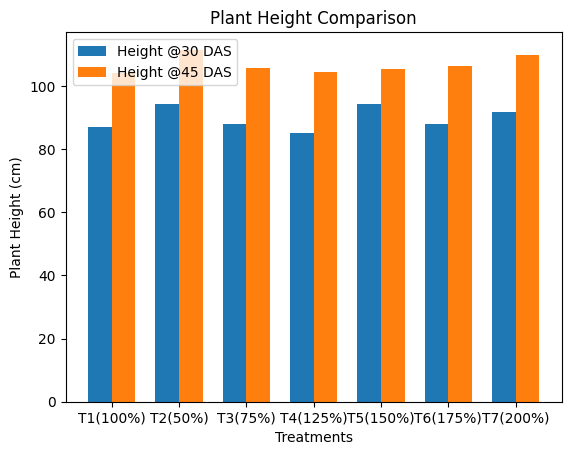

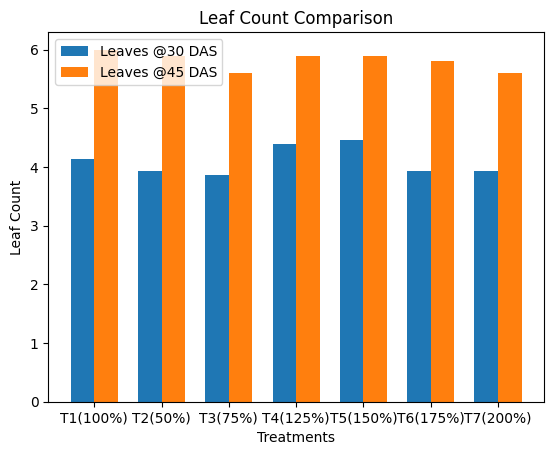

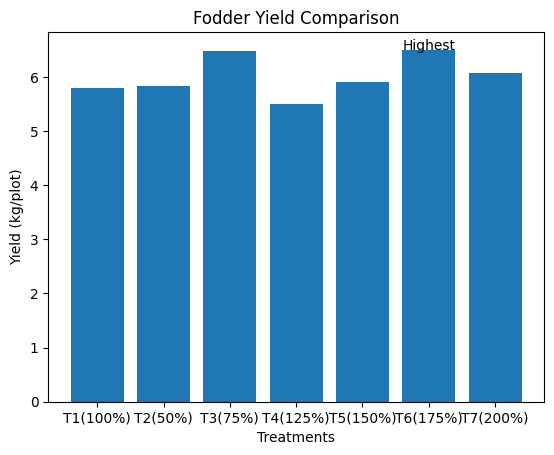

In [ ]:
#matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Treatments
treatments = ['T1(100%)','T2(50%)','T3(75%)','T4(125%)','T5(150%)','T6(175%)','T7(200%)']

# Data from your report
ht_30 = [86.93, 94.26, 88.06, 85.13, 94.4, 87.93, 91.8]
ht_45 = [104, 111.53, 105.6, 104.6, 105.5, 106.3, 110]

leaves_30 = [4.13, 3.93, 3.86, 4.4, 4.46, 3.93, 3.93]
leaves_45 = [6.0, 5.9, 5.6, 5.9, 5.9, 5.8, 5.6]

yield_kg = [5.80, 5.83, 6.47, 5.50, 5.90, 6.50, 6.07]

x = np.arange(len(treatments))
width = 0.35

# -----------------------------
# 1. Plant Height Comparison
# -----------------------------
plt.figure()
plt.bar(x - width/2, ht_30, width, label='Height @30 DAS')
plt.bar(x + width/2, ht_45, width, label='Height @45 DAS')

plt.xticks(x, treatments)
plt.xlabel("Treatments")
plt.ylabel("Plant Height (cm)")
plt.title("Plant Height Comparison")
plt.legend()
plt.show()


# -----------------------------
# 2. Leaf Count Comparison
# -----------------------------
plt.figure()
plt.bar(x - width/2, leaves_30, width, label='Leaves @30 DAS')
plt.bar(x + width/2, leaves_45, width, label='Leaves @45 DAS')

plt.xticks(x, treatments)
plt.xlabel("Treatments")
plt.ylabel("Leaf Count")
plt.title("Leaf Count Comparison")
plt.legend()
plt.show()


# -----------------------------
# 3. Yield Comparison
# -----------------------------
plt.figure()
plt.bar(treatments, yield_kg)

plt.xlabel("Treatments")
plt.ylabel("Yield (kg/plot)")
plt.title("Fodder Yield Comparison")

# Highlight best treatment
best_index = np.argmax(yield_kg)
plt.text(best_index, yield_kg[best_index], "Highest", ha='center')

plt.show()

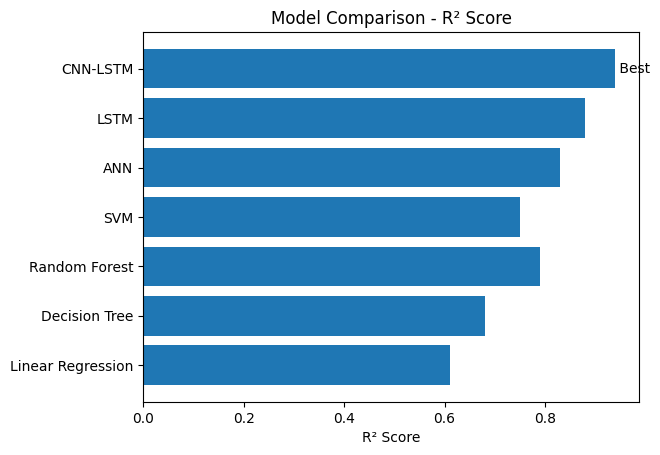

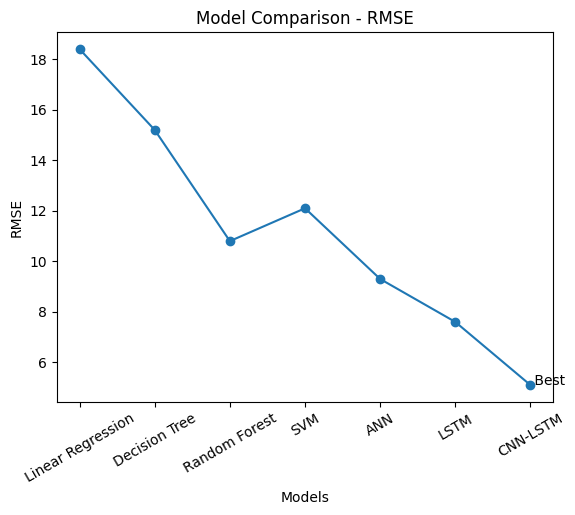

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models from your report
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVM', 'ANN', 'LSTM', 'CNN-LSTM']

# Values from your report
r2_scores = [0.61, 0.68, 0.79, 0.75, 0.83, 0.88, 0.94]
rmse_values = [18.4, 15.2, 10.8, 12.1, 9.3, 7.6, 5.1]

x = np.arange(len(models))

# -----------------------------
# 1. R² Score Comparison
# -----------------------------
plt.figure()
plt.barh(models, r2_scores)

plt.xlabel("R² Score")
plt.title("Model Comparison - R² Score")

# Highlight best model
best_r2 = np.argmax(r2_scores)
plt.text(r2_scores[best_r2], best_r2, " Best", va='center')

plt.show()


# -----------------------------
# 2. RMSE Comparison
# -----------------------------
plt.figure()
plt.plot(models, rmse_values, marker='o')

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")

# Highlight lowest RMSE
best_rmse = np.argmin(rmse_values)
plt.text(best_rmse, rmse_values[best_rmse], " Best")

plt.xticks(rotation=30)
plt.show()

# Welcome to Colab!

## Google Colab is available in VS Code!
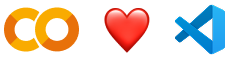

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## 🎁 Free Pro Plan for Gemini & Colab for US College Students 🎓

Get more access to our most accurate model Gemini 3 Pro for advanced coding, complex research, and innovative projects, backed by Colab’s dedicated high-compute resources for data science and machine learning.

Get the Gemini free offer at [gemini.google/students](https://gemini.google/students?utm_source=colab&utm_medium=banner&utm_campaign=students_xpa_us-colab-banner).  
Get the Colab free offer at [colab.research.google.com/signup](https://colab.research.google.com/signup).  
Terms Apply.

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
This cell's functionality (loading data) is already included in the comprehensive machine learning pipeline defined in cell `BwXYG5Eo7-29`.

,N_P_pct,ht_30,ht_45,leaves_30,leaves_45,yield_kg
0,100,86.93,104.00,4.13,6.0,5.80
1,50,94.26,111.53,3.93,5.9,5.83
2,75,88.06,105.60,3.86,5.6,6.47
3,125,85.13,104.60,4.40,5.9,5.50
4,150,94.40,105.50,4.46,5.9,5.90


In [ ]:
This cell's functionality (splitting data) is already included in the comprehensive machine learning pipeline defined in cell `BwXYG5Eo7-29`.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
